### Part 1
![saved_map.png](saved_map.png)

### Part 2
a) No, the maximal reactions here are different for all maximal reaction activities. This does not change the fact of mass balance constraint - the fluxes are still balanced. Numbers on the map indicate how much flux this reaction is able to carry out. They are the upper bounds for the model.

b) The values are "nd" (no data) or 0.00. The 0.00 represents the enzyme constraint put in the model, which does not allow the reaction to carry any flux. nd means that the measurement was not possible.

In [1]:
import pandas as pd
import cobra

model = cobra.io.load_json_model("e_coli_core-1.json")

df = pd.read_csv("KEN3170_Assignment_2026_e_coli_core_expression.csv")

In [2]:
# implementing maximum reaction activity for all reactions in model

for reaction_id, value in zip(df["# Reaction ID"], df[" reaction activity [mmol/gDW/h] "]):
    reaction = model.reactions.get_by_id(reaction_id)

    if value == "nd":
        continue

    if reaction.id == "ATPM":
        reaction.upper_bound = value
        continue

    if reaction.reversibility:
        model.reactions.get_by_id(reaction_id).bounds = (-value, value)
    elif not reaction.reversibility:
        model.reactions.get_by_id(reaction_id).bounds = (0, value)

model.reactions.EX_glc__D_e.lower_bound = -1000

for reaction in model.reactions:
    print(reaction.id, reaction.bounds)

PFK (0, 13.1)
PFL (0, 0.0)
PGI (-11.1, 11.1)
PGK (-24.0, 24.0)
PGL (0, 7.3)
ACALD (-0.0, 0.0)
AKGt2r (-0.0, 0.0)
PGM (-21.7, 21.7)
PIt2r (-5.2, 5.2)
ALCD2x (-0.0, 0.0)
ACALDt (-1000.0, 1000.0)
ACKr (-2.5, 2.5)
PPC (0, 3.6)
ACONTa (-21.4, 21.4)
ACONTb (-21.4, 21.4)
ATPM (8.39, 1000.0)
PPCK (0, 13.3)
ACt2r (-3.6, 3.6)
PPS (0, 3.1)
ADK1 (-27.4, 27.4)
AKGDH (0, 26.7)
ATPS4r (-80.1, 80.1)
PTAr (-4.47, 4.47)
PYK (0, 28.2)
BIOMASS_Ecoli_core_w_GAM (0.0, 1000.0)
PYRt2 (-0.0, 0.0)
CO2t (-1000.0, 1000.0)
RPE (-6.3, 6.3)
CS (0, 21.4)
RPI (-5.6, 5.6)
SUCCt2_2 (0, 0.0)
CYTBD (0, 41.1)
D_LACt2 (-0.0, 0.0)
ENO (-29.3, 29.3)
SUCCt3 (0, 0.0)
ETOHt2r (-1000.0, 1000.0)
SUCDi (0, 27.3)
SUCOAS (-19.4, 19.4)
TALA (-4.5, 4.5)
THD2 (0, 6.5)
TKT1 (-3.5, 3.5)
TKT2 (-3.5, 3.5)
TPI (-70.0, 70.0)
EX_ac_e (0.0, 1000.0)
EX_acald_e (0.0, 1000.0)
EX_akg_e (0.0, 1000.0)
EX_co2_e (-1000.0, 1000.0)
EX_etoh_e (0.0, 1000.0)
EX_for_e (0.0, 1000.0)
EX_fru_e (0.0, 1000.0)
EX_fum_e (0.0, 1000.0)
EX_glc__D_e (-1000, 1000.0)
EX_

In [3]:
##  safety check
print(model.reactions.EX_glc__D_e.bounds)
print(model.reactions.ATPM.bounds)

(-1000, 1000.0)
(8.39, 1000.0)


### Part 3


In [4]:
## 3a

solution = model.optimize()

print("Maximum biomass production rate:", solution.objective_value)

Maximum biomass production rate: 0.8732862458582372


Max biomass production rate is 0.8733 h⁻¹ (4 d.p.)

In [5]:
## 3b

model.reactions.EX_glc__D_e.lower_bound =-5

print("Glucose exchange bounds:", model.reactions.EX_glc__D_e.bounds)

Glucose exchange bounds: (-5, 1000.0)


The -5 represents the limit of glucose the cell can get from its environment, measured in mmol/gDW/h. In exercise 2, the expression-based constraints were tied to the maximum capacity of internal reactions, which is known through enzyme levels. In this case, a hard limit of 5 mmol/gDW/h limits glucose uptake, which in extension limits energy and bioimass production.

In [6]:
##  3c
solution_limited_glucose = model.optimize()

print("Maximum biomass production rate with glucose limit:", solution_limited_glucose.objective_value)

Maximum biomass production rate with glucose limit: 0.4155977750929063


With this hard limit, maximal biomass production decreased from 0.8733 to 0.4156mmol/gDW/h , which is  over 52% of a decrease, showing that limited glucose uptake can harm or slow growth. This makes sense because, as mentioned in 3b, with less glucose entering the cell, there is less energy available for biomass production, and therefore the maximum growth rate will be lower.

### Part 4

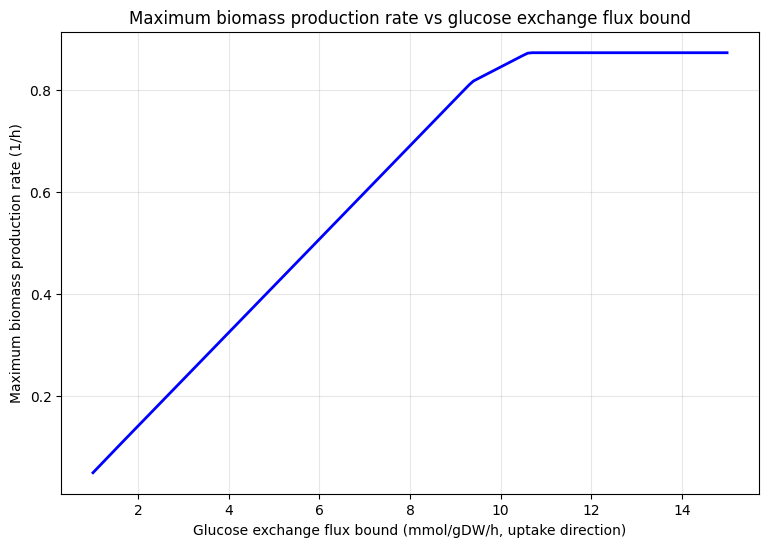

biomass at bound  1.0: 0.0484
biomass at bound 10.0: 0.8452
biomass at bound 15.0: 0.8733


In [7]:
## 4a

import numpy as np
import matplotlib.pyplot as plt

# glucose exchange flux bound from 1 to 15 mmol/gDW/h, in steps of 0.1
glucose_bounds = np.arange(1, 15.01, 0.1)
biomass_rates = []

for bound in glucose_bounds:
    # negative lower bound = uptake direction
    model.reactions.EX_glc__D_e.lower_bound = -bound
    biomass_rates.append(model.optimize().objective_value)

plt.figure(figsize=(9, 6))
plt.plot(glucose_bounds, biomass_rates, 'b-', linewidth=2)
plt.xlabel('Glucose exchange flux bound (mmol/gDW/h, uptake direction)')
plt.ylabel('Maximum biomass production rate (1/h)')
plt.title('Maximum biomass production rate vs glucose exchange flux bound')
plt.grid(True, alpha=0.3)
plt.show()

print(f"biomass at bound  1.0: {biomass_rates[0]:.4f}")
print(f"biomass at bound 10.0: {biomass_rates[90]:.4f}")
print(f"biomass at bound 15.0: {biomass_rates[-1]:.4f}")

### 4b

No. The growth rate goes up until about 10.6 mmol/gDW/h and then stays flat at 0.8733 1/h.

The reason is that the enzyme constraints we added in Part 2 fill up. First the cell reaches its
maximum oxygen use, so it cannot burn all the glucose any more and starts making acetate instead.
Then it also reaches its maximum acetate production, so the glucose uptake cannot go higher either.
After that point, allowing more glucose does not change anything.

So the growth rate is limited by the enzymes inside the cell, not by how much glucose is available.

In [8]:
## 4c - check which exchange reactions carry flux in each segment

for bound in [9.0, 10.0, 13.0]:
    model.reactions.EX_glc__D_e.lower_bound = -bound
    solution = model.optimize()
    print(f"glucose bound = {bound}, biomass = {solution.objective_value:.4f}")
    for reaction in model.reactions:
        if reaction.id.startswith("EX_") and abs(solution.fluxes[reaction.id]) > 1e-6:
            print(f"   {reaction.id:<14} {solution.fluxes[reaction.id]:8.3f}")
    print()

glucose bound = 9.0, biomass = 0.7823
   EX_co2_e         20.711
   EX_glc__D_e      -9.000
   EX_h_e           15.692
   EX_h2o_e         26.409
   EX_nh4_e         -4.265
   EX_o2_e         -19.806
   EX_pi_e          -2.878

glucose bound = 10.0, biomass = 0.8452
   EX_ac_e           1.252
   EX_co2_e         21.527
   EX_glc__D_e     -10.000
   EX_h_e           18.207
   EX_h2o_e         27.684
   EX_nh4_e         -4.609
   EX_o2_e         -20.550
   EX_pi_e          -3.109

glucose bound = 13.0, biomass = 0.8733
   EX_ac_e           2.500
   EX_co2_e         21.560
   EX_glc__D_e     -10.620
   EX_h_e           20.018
   EX_h2o_e         27.921
   EX_nh4_e         -4.762
   EX_o2_e         -20.550
   EX_pi_e          -3.213



### 4c

**`EX_ac_e`** (acetate exchange).

Its flux is 0 at a glucose bound of 9.0 but 1.25 at 10.0, so acetate secretion is what starts in the
second segment.